#**OASIS Infobyte — Retail Sales Analysis**

**Track:** Data Analytics

**Task:** Retail Sales Analysis

**Tools:** Python, Pandas, Matplotlib, Google Colab

###**Project Overview**

This project analyzes retail sales data to identify sales trends, customer purchasing patterns, and product category performance. The analysis includes data cleaning, exploratory data analysis, visualization, and business recommendations.

# **A. Load dataset and perform initial inspection: shape, column dtypes, null value**


- ## **Data Loading and Preparation**


The dataset was loaded into Python using Pandas. The data was then inspected to understand its structure, identify missing values and duplicates, correct column naming issues, and prepare the data for analysis.


In [3]:
import pandas as pd

df = pd.read_csv("Retail_Sales.csv")

In [4]:
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


- **Size of the dataset**

In [5]:
df.shape

(2000, 11)

- **Check the column names**

In [6]:
df.columns

Index(['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender',
       'age', 'category', 'quantiy', 'price_per_unit', 'cogs', 'total_sale'],
      dtype='object')

- **Check the data types**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transactions_id  2000 non-null   int64  
 1   sale_date        2000 non-null   object 
 2   sale_time        2000 non-null   object 
 3   customer_id      2000 non-null   int64  
 4   gender           2000 non-null   object 
 5   age              1990 non-null   float64
 6   category         2000 non-null   object 
 7   quantiy          1997 non-null   float64
 8   price_per_unit   1997 non-null   float64
 9   cogs             1997 non-null   float64
 10  total_sale       1997 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB


- **Confirm missing values**

In [8]:
df.isnull().sum()

,0
transactions_id,0
sale_date,0
sale_time,0
customer_id,0
gender,0
age,10
category,0
quantiy,3
price_per_unit,3
cogs,3


- **Rows with missing data**

In [9]:
df[df.isnull().any(axis=1)]

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
24,432,2022-03-10,11:31:00,17,Female,NaN,Electronics,2.0,500.0,190.00,1000.0
25,1367,2022-04-15,11:38:00,16,Female,NaN,Electronics,1.0,50.0,15.50,50.0
26,1391,2022-03-01,11:29:00,130,Male,NaN,Beauty,2.0,25.0,9.25,50.0
27,1432,2022-12-25,06:24:00,67,Female,NaN,Electronics,2.0,500.0,245.00,1000.0
28,150,2022-04-13,08:25:00,89,Female,NaN,Electronics,4.0,30.0,16.20,120.0
29,845,2022-10-27,10:12:00,25,Male,NaN,Clothing,1.0,500.0,145.00,500.0
30,1150,2022-08-22,10:04:00,77,Female,NaN,Electronics,4.0,30.0,10.20,120.0
31,1845,2022-05-24,07:06:00,94,Male,NaN,Clothing,1.0,500.0,185.00,500.0
32,797,2022-09-16,06:38:00,116,Male,NaN,Clothing,3.0,25.0,10.75,75.0
33,921,2022-09-28,09:34:00,101,Male,NaN,Electronics,3.0,25.0,8.00,75.0


- **Inspect the dataset for duplicate rows**

In [10]:
df.duplicated().sum()

np.int64(0)

- **Fix column name typo**

In [11]:
df.rename(columns={'quantiy': 'quantity'}, inplace=True)

In [12]:
df.columns

Index(['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender',
       'age', 'category', 'quantity', 'price_per_unit', 'cogs', 'total_sale'],
      dtype='object')

- **Rechecking missing values again**

In [13]:
df.isnull().sum()

,0
transactions_id,0
sale_date,0
sale_time,0
customer_id,0
gender,0
age,10
category,0
quantity,3
price_per_unit,3
cogs,3


- **Handle the 10 missing ages**

In [14]:
df['age'].median()

42.0

- **Fill the missing ages**

In [15]:
df['age'] = df['age'].fillna(df['age'].median())

In [16]:
df['age'].isnull().sum()

np.int64(0)

- **Remove the 3 incomplete sales transaction - as we don't want to makeup financial data**

In [17]:
df = df.dropna(subset=['quantity', 'price_per_unit', 'cogs', 'total_sale'])

In [18]:
df.isnull().sum()

,0
transactions_id,0
sale_date,0
sale_time,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price_per_unit,0
cogs,0


- **Inspect clean data**

In [19]:
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantity,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


In [20]:
df.shape

(1997, 11)

- **Convert `sale_date` to proper date**

In [21]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1997 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transactions_id  1997 non-null   int64         
 1   sale_date        1997 non-null   datetime64[ns]
 2   sale_time        1997 non-null   object        
 3   customer_id      1997 non-null   int64         
 4   gender           1997 non-null   object        
 5   age              1997 non-null   float64       
 6   category         1997 non-null   object        
 7   quantity         1997 non-null   float64       
 8   price_per_unit   1997 non-null   float64       
 9   cogs             1997 non-null   float64       
 10  total_sale       1997 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2), object(3)
memory usage: 251.8+ KB


# **B. Descriptive Statistics: Mean, Median, Mode and Standard Deviation**


- ## **Exploratory Data Analysis**

Descriptive statistics were used to understand the numerical characteristics of the dataset, including age, quantity, price per unit, cost of goods sold, and total sales.


In [23]:
df.describe()

,transactions_id,sale_date,customer_id,age,quantity,price_per_unit,cogs,total_sale
count,1997.000000,1997,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000
mean,1000.676014,2023-02-17 07:34:16.885327872,66.319479,41.354532,2.512769,180.117677,95.023886,456.544817
min,1.000000,2022-01-01 00:00:00,1.000000,18.000000,1.000000,25.000000,6.250000,25.000000
25%,500.000000,2022-09-23 00:00:00,24.000000,29.000000,1.000000,30.000000,13.000000,60.000000
50%,1001.000000,2023-01-14 00:00:00,69.000000,42.000000,3.000000,50.000000,27.500000,150.000000
75%,1501.000000,2023-09-14 00:00:00,102.000000,53.000000,4.000000,300.000000,147.000000,900.000000
max,2000.000000,2023-12-31 00:00:00,155.000000,64.000000,4.000000,500.000000,620.000000,2000.000000
std,577.833658,NaN,44.939785,13.628462,1.132708,189.685225,121.898695,560.101381


In [24]:
# Numerical descriptive statistics required by the OASIS checklist
numerical_cols = df.select_dtypes(include='number').columns

descriptive_stats = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': df[numerical_cols].mode().iloc[0],
    'Standard Deviation': df[numerical_cols].std()
})

descriptive_stats


,Mean,Median,Mode,Standard Deviation
transactions_id,1000.676014,1001.0,1.0,577.833658
customer_id,66.319479,69.0,1.0,44.939785
age,41.354532,42.0,42.0,13.628462
quantity,2.512769,3.0,4.0,1.132708
price_per_unit,180.117677,50.0,50.0,189.685225
cogs,95.023886,27.5,13.5,121.898695
total_sale,456.544817,150.0,50.0,560.101381


#### **Observation**
The descriptive statistics show the central tendency and variability of the numerical variables. For example, the median total sale is lower than the mean total sale, indicating that some higher-value transactions increase the average sales value.


- **Find the sales by category**

#**C. Time series analysis: plot monthly and quarterly sales trends using line charts**

**Monthly Sales Trend**

Monthly total sales were calculated to identify changes in sales performance over time and highlight periods with relatively higher or lower sales.

In [34]:
# Sales over time

df['month'] = df['sale_date'].dt.to_period('M')

In [35]:
monthly_sales = df.groupby(df['sale_date'].dt.to_period('M'))['total_sale'].sum()

monthly_sales

,total_sale
sale_date,
2022-01,22635.0
2022-02,16110.0
2022-03,24505.0
2022-04,28705.0
2022-05,24980.0
2022-06,20700.0
2022-07,22195.0
2022-08,21195.0
2022-09,61770.0


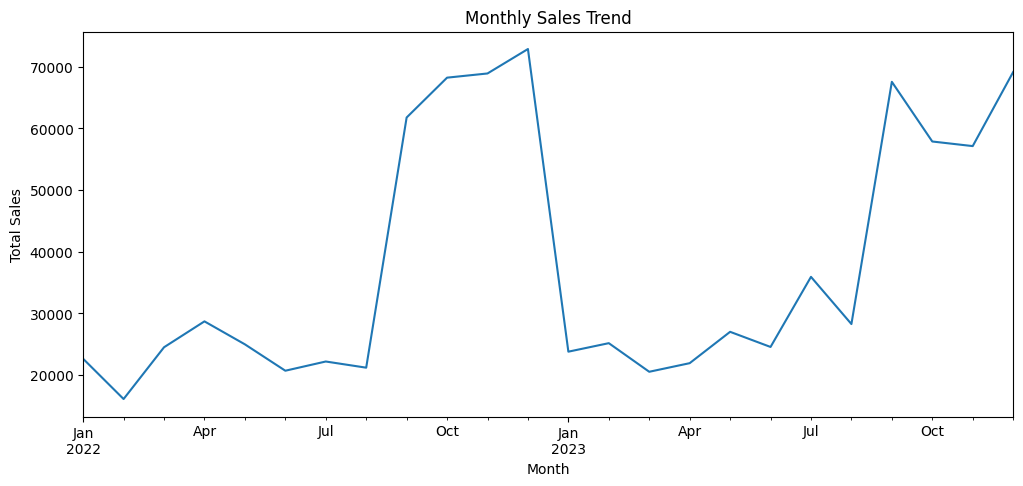

In [37]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', figsize=(12, 5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

#### **Observation:** Monthly sales fluctuate throughout the period, with some months recording higher sales than others. This shows changes in sales performance over time and can help guide inventory and promotional planning.

**Quarterly Sales Trend**

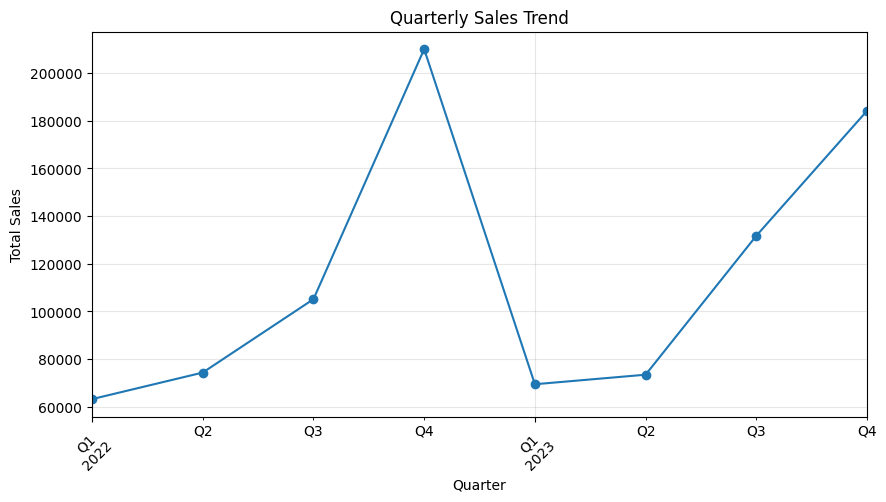

In [48]:
quarterly_sales = (
    df.groupby(df['sale_date'].dt.to_period('Q'))['total_sale']
      .sum()
)

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind='line', marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


####**Observation:** Quarterly sales show fluctuations across the periods, with some quarters recording higher sales than others. This indicates variations in sales performance over time and can help guide inventory and promotional planning.

#**D. Customer demographics analysis: distribution of customer age groups, gender breakdown**


- ## **Sales Performance by Gender**

This section compares sales performance and transaction activity between male and female customers to identify differences in purchasing behaviour.

In [29]:
# Sales by gender

df.groupby('gender')['total_sale'].sum().sort_values(ascending=False)

,total_sale
gender,
Female,465400.0
Male,446320.0


- ## **Sales Performance by Age Group**

Customers were grouped into age ranges to examine how sales performance varies across different customer age groups.

In [31]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 55, 64],
    labels=['18-25', '26-35', '36-45', '46-55', '56-64']
)

In [32]:
df['age_group'].value_counts().sort_index()

,count
age_group,
18-25,336
26-35,409
36-45,413
46-55,455
56-64,384


In [33]:
# Total sales by age_group

df.groupby('age_group')['total_sale'].sum().sort_values(ascending=False)

/tmp/ipykernel_4935/3315148924.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['total_sale'].sum().sort_values(ascending=False)


,total_sale
age_group,
46-55,200305.0
26-35,196870.0
36-45,187155.0
18-25,168960.0
56-64,158430.0


# **E. Product analysis: top 10 best-selling products; revenue by product category (bar chart)**


- ## **Sales Performance by Product Category**

This section examines transaction volume, total sales, average sales, and quantity sold across the different product categories.

- **Total Sales by Category**

In [25]:
df.groupby('category')['total_sale'].sum().sort_values(ascending=False)

,total_sale
category,
Electronics,313810.0
Clothing,311070.0
Beauty,286840.0


- **Count transactions by gender**


In [49]:
df['gender'].value_counts()

,count
gender,
Female,1017
Male,980


- **Count transactions by category**

In [26]:
df['category'].value_counts()

,count
category,
Clothing,701
Electronics,684
Beauty,612


- **Total sales for each category**

In [27]:
df.groupby('category')['total_sale'].sum().sort_values(ascending=False)

,total_sale
category,
Electronics,313810.0
Clothing,311070.0
Beauty,286840.0


- **Average sale for each category**

In [50]:
df.groupby('category')['total_sale'].mean().sort_values(ascending=False)

,total_sale
category,
Beauty,468.692810
Electronics,458.786550
Clothing,443.751783


- **Sales by Gender and Product Category**

This analysis examines the relationship between customer gender and product category to identify which categories generate the highest sales among male and female customers.

In [40]:
# Product category each gender buys the most

gender_category = df.groupby(['gender', 'category'])['total_sale'].sum()
gender_category

gender  category   
Female  Beauty         149470.0
        Clothing       162460.0
        Electronics    153470.0
Male    Beauty         137370.0
        Clothing       148610.0
        Electronics    160340.0
Name: total_sale, dtype: float64


  This section examines the number of units sold across product categories and identifies customers with the highest total spending.

In [45]:
# Best-selling categories by quantity (the finest product-level grouping available in this dataset)
category_quantity = (
    df.groupby('category')['quantity']
      .sum()
      .sort_values(ascending=False)
)

category_quantity


,quantity
category,
Clothing,1785.0
Electronics,1698.0
Beauty,1535.0


- ### **Top 10 customers by total spending**

In [39]:
top_customers = df.groupby('customer_id')['total_sale'].sum().sort_values(ascending=False).head(10)
top_customers

,total_sale
customer_id,
3,38440.0
1,30750.0
5,30405.0
2,25295.0
4,23580.0
87,15855.0
54,13475.0
71,12790.0
55,12080.0


# **F. Heatmap: correlation matrix between numerical variables**

The official checklist requires a heatmap showing correlations among numerical variables.


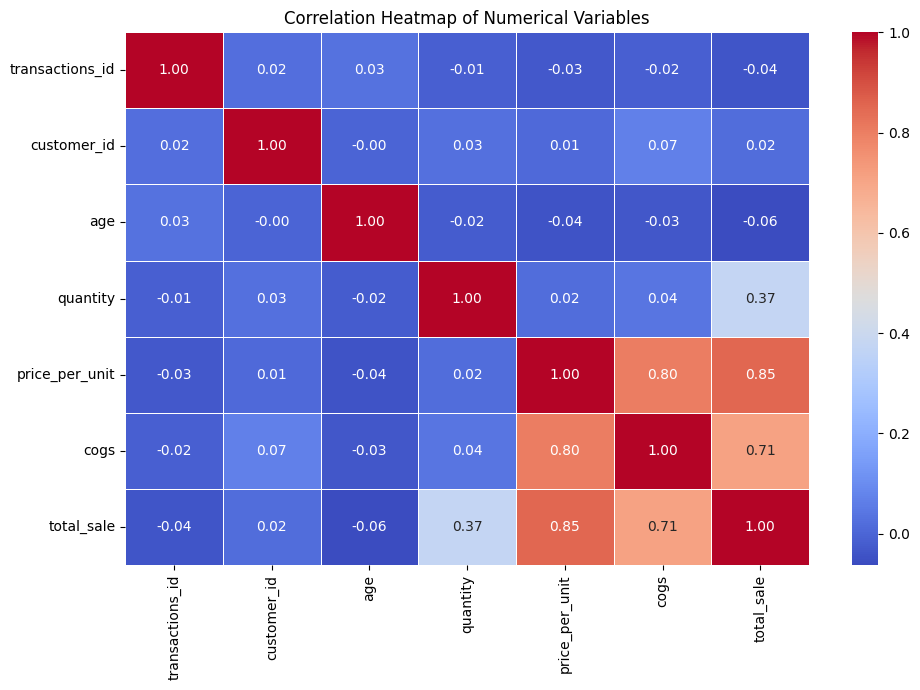

In [46]:
import seaborn as sns

# Correlation matrix for numerical variables
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()


#### **Observation**: The heatmap shows how the numerical variables move in relation to one another. In particular, total sales are strongly related to quantity and price per unit because total sales are calculated from sales quantities and prices. Correlation should be interpreted as association, not proof of causation.


#**G. Data Visualization**


- **Sales by category chart**

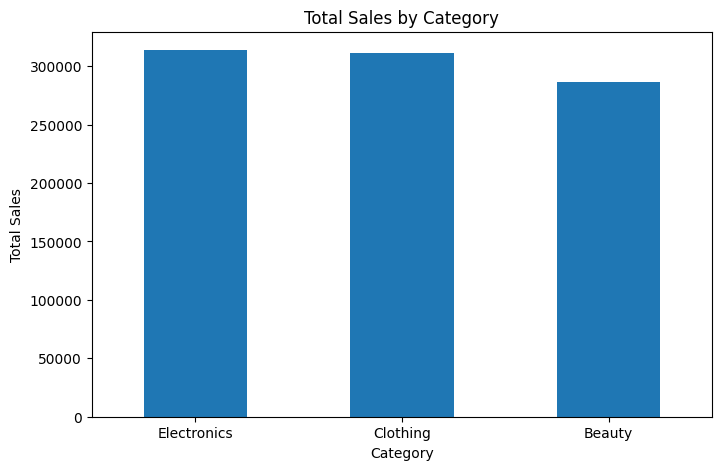

In [41]:
category_sales = df.groupby('category')['total_sale'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar', figsize=(8, 5))

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

**Observation:** Total Sales by Category

Electronics generated the highest total sales at ₦313,810, followed closely by Clothing at ₦311,070. Beauty recorded the lowest total sales at ₦286,840.

Although Electronics generated the highest sales value, Clothing had the highest quantity sold with 1,785 units. This shows that a higher number of units sold does not necessarily result in the highest total sales, since product prices also affect revenue.

- **Sales by Gender**

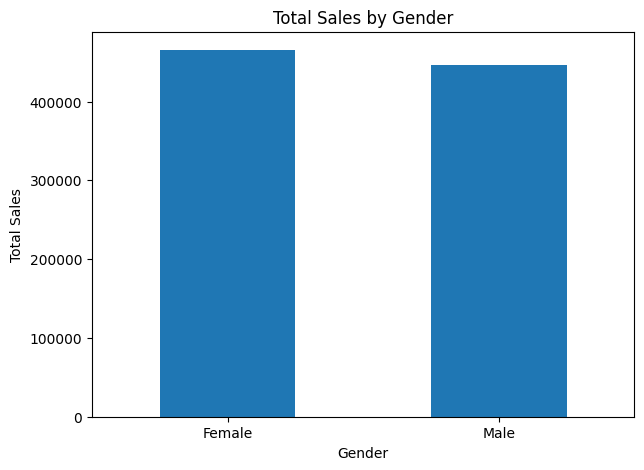

In [42]:
gender_sales = df.groupby('gender')['total_sale'].sum().sort_values(ascending=False)

gender_sales.plot(kind='bar', figsize=(7, 5))

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

**Observation:** Total Sales by Gender

Female customers generated ₦465,400 in total sales, while male customers generated ₦446,320. Female customers also recorded slightly more transactions, with 1,017 transactions compared with 980 for male customers.

The difference is relatively small, so the business should continue serving both customer groups while monitoring their purchasing patterns over time.


- **Additional Visualization — Sales Distribution by Category**

This visualization provides an additional view that is different from the existing total-sales bar chart. It helps reveal the spread of individual transaction values within each category.


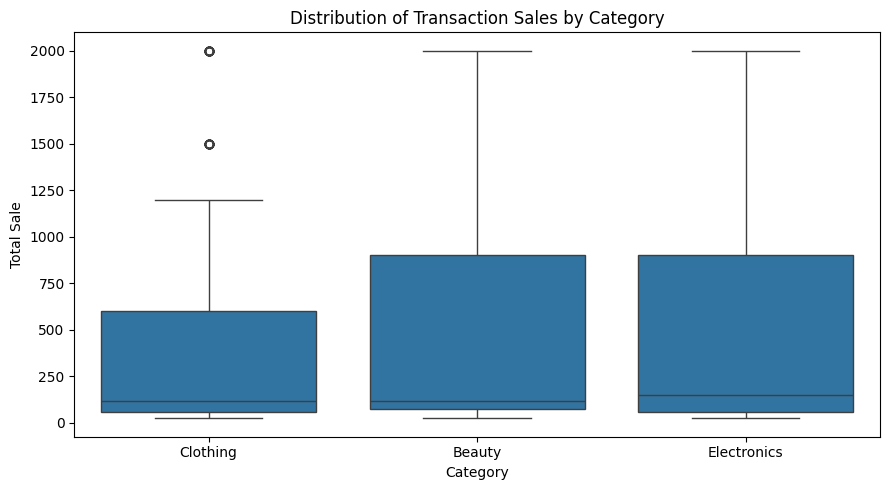

In [47]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='category', y='total_sale')
plt.title('Distribution of Transaction Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sale')
plt.tight_layout()
plt.show()


### **Observation**: The boxplot shows the distribution and spread of transaction values within each category. It can reveal whether a category's total sales are driven by many moderate transactions or by a smaller number of unusually high-value transactions.


##**Conclusion**

The retail sales analysis provided useful insights into sales performance, customer behaviour, product categories, and monthly sales trends. Electronics generated the highest total sales, while Clothing recorded the highest quantity of units sold. Female customers generated slightly higher total sales than male customers, and customers aged 46–55 recorded the highest total sales among the age groups analysed. The analysis also showed noticeable variation in monthly sales.

##**Business Recommendations**

1. Increase focus on Electronics: Since Electronics generated the highest total sales, the business should maintain sufficient inventory for electronic products and consider targeted promotions to increase their sales further

2. Strengthen Clothing sales: Clothing recorded the highest quantity sold but ranked second in total sales. The business could review clothing prices, product combinations, and promotional strategies to improve the revenue generated from these high-volume products.

3. Plan inventory and promotions around high-sales periods: Since monthly sales varied considerably, the business should use previous sales patterns to prepare inventory and marketing campaigns ahead of months with historically higher demand.

4. Develop targeted customer strategies: Female customers generated slightly higher total sales than male customers. The business can analyse the purchasing behaviour of both groups further and create targeted offers based on their preferred product categories.

5. Monitor high-value customers: Customer 3 recorded the highest total spending at ₦38,440. The business should identify and monitor high-value customers and consider loyalty programmes or personalised offers to encourage repeat purchases.